# Calculo de Eigenvalores para un modelo de BTC (Boundary Time Crystals) https://arxiv.org/abs/1708.05014
 Importamos librerias importantes, principalmente qutip que ya nos hace la vectorización para el Liouvilliano y para definir los operadores e incluso para realizar los productos tensoriales de manera sencilla

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

vec1= basis(5,2) 
up = basis(2,0) # (1,0)
down = basis(2,1) # (0,1)

upx = (basis(2,0) + basis(2,1)).unit() # Initial state “The system is initialised in the pure state with all spins aligned along the x-direction…”

Probando como hacer matrices de densidad y trazas parciales usando las funciones de qutip

In [11]:
# Matriz de densidad para 2 espines

psi = (1/np.sqrt(2))*(1/np.sqrt(2))*(tensor(up,down) - tensor(down,up)) 

rho = psi * psi.dag()

rho_0 = rho.ptrace(0) # Tr_1 rho
rho_1 = rho.ptrace(1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


## Queremos obtener los eigenvalores del Liouvilliano
En general y en la función de qutip 

$$\mathcal{L}[\rho] = i[\rho, H] + \left( L\rho L^{\dagger} - \frac{1}{2} \{L^{\dagger}L, \rho\} \right) = \lambda \rho$$

En el modelo usan el siguiente Hamiltoniano

$$H = \omega_0 \sum_j \sigma^x_j$$
En el paper usan la siguiente expresión ya simplificada

$$\mathcal{L}[\rho] = i\omega_0[\rho, S^x] + \frac{\kappa}{S}\left( S_{-}\rho S_{+} - \frac{1}{2} \{S_{+}S_{-}, \rho\} \right)$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

vec1= basis(5,2) 
up = basis(2,0) # (1,0)
down = basis(2,1) # (0,1)

upx = (basis(2,0) + basis(2,1)).unit() # Initial state “The system is initialised in the pure state with all spins aligned along the x-direction…”

Nb = 36 # Spin en la frontera (boundary)
S = Nb/2 # Spin total
k = 1
w_0 = 1.5*k

# Defining spin operators
Sx = jmat(S, 'x')
Sy = jmat(S, 'y')
Sz = jmat(S, 'z')
S2 = Sx**2 + Sy**2 + Sz**2
Sm = np.sqrt(k/S)*jmat(S, '-')
#Sp = np.sqrt(k/S)*jmat(S, '+')

H = w_0*Sx

jump_ops = [Sm]
expected_ops = [S2,Sx,Sy,Sz,Sm]

L = liouvillian(H, jump_ops)
eigs = L.eigenenergies()

# initial states
psi0z = (basis(int(2*S+1), int(S))).unit()
rho0z = (psi0z * psi0z.dag())

# rotate from z to x
rho0x = ( (-1j * np.pi/2 * Sy).expm() * rho0z * (1j * np.pi/2 * Sy).expm() )

t = np.linspace(0, 60, 120)

evo1 = mesolve(H, rho0x, t, jump_ops, expected_ops)
evo2 = mesolve(H, rho0z, t, jump_ops, expected_ops)

print(evo1,evo2)

C:\Users\Arturo\.conda\envs\QMPhysics\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.00024247169494628906
    preparation time: 0.0003151893615722656
    run time: 1.828444242477417
    solver: 'Master Equation Evolution'
    num_collapse: 1
  Time interval: [0.0, 60.0] (120 steps)
  Number of e_ops: 5
  State not saved.
> <Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 7.224082946777344e-05
    preparation time: 0.0002148151397705078
    run time: 5.84514045715332
    solver: 'Master Equation Evolution'
    num_collapse: 1
  Time interval: [0.0, 60.0] (120 steps)
  Number of e_ops: 5
  State not saved.
>


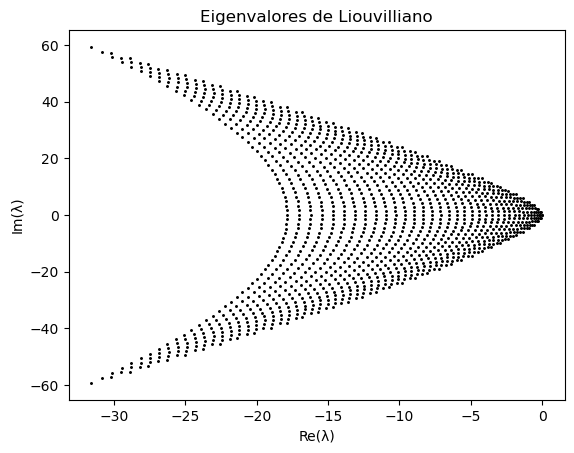

C:\Users\Arturo\.conda\envs\QMPhysics\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Arturo\.conda\envs\QMPhysics\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


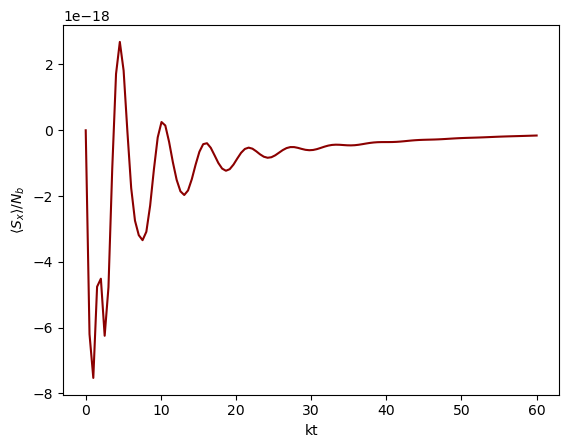

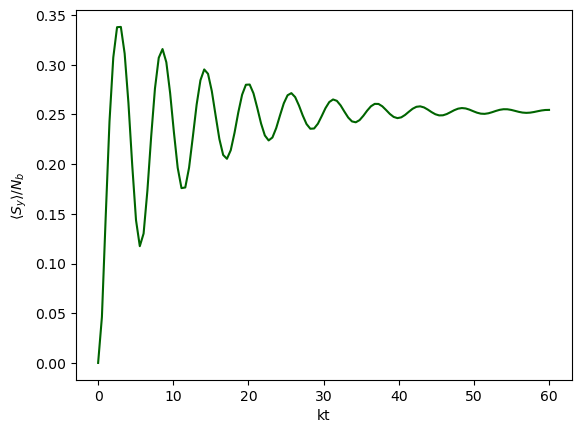

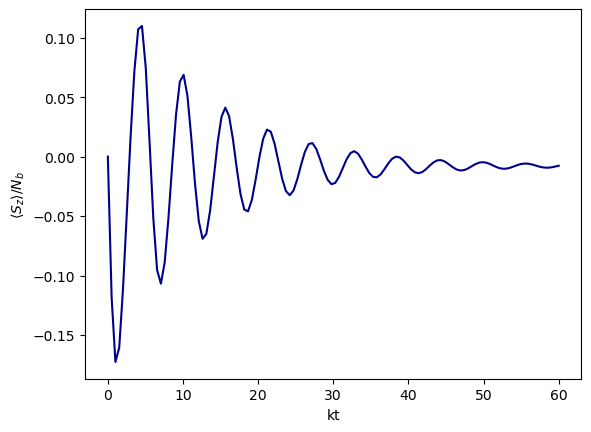

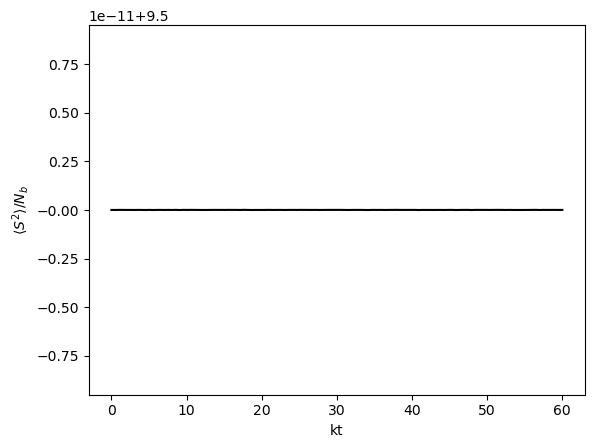

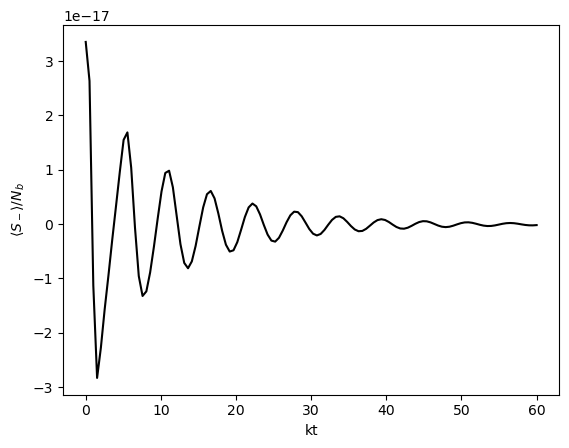

In [3]:
X = np.real(eigs)
Y = np.imag(eigs)

plt.scatter(X,Y, s=1.25, c='black')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalores de Liouvilliano")
#plt.savefig("evalues100.png")
plt.show()


# rho0 = all spin up in x
plt.plot( k*t, evo1.expect[1]/Nb, c='darkred')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_x\rangle / N_b$")
plt.show()

plt.plot( k*t, evo1.expect[2]/Nb, c='darkgreen')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_y\rangle / N_b$")
plt.show()

plt.plot( k*t, evo1.expect[3]/Nb, c='darkblue')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_z\rangle / N_b$")
#plt.savefig("dyn100z.png")
plt.show()

plt.plot( k*t, evo1.expect[0]/Nb, c='black')
plt.xlabel("kt")
plt.ylabel(r"$\langle S^2\rangle / N_b$")
plt.show()

plt.plot( k*t, evo1.expect[4]/Nb, c='black')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_-\rangle / N_b$")
plt.show()


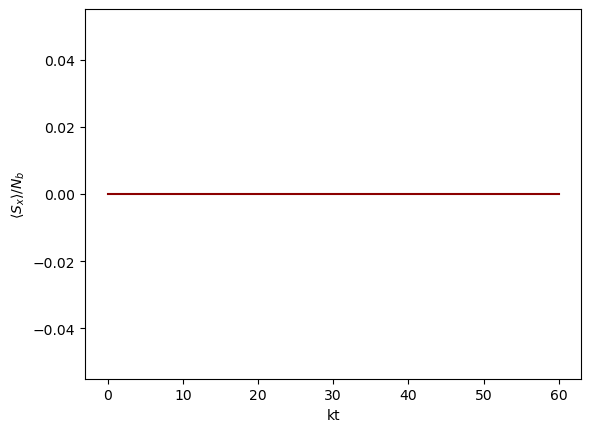

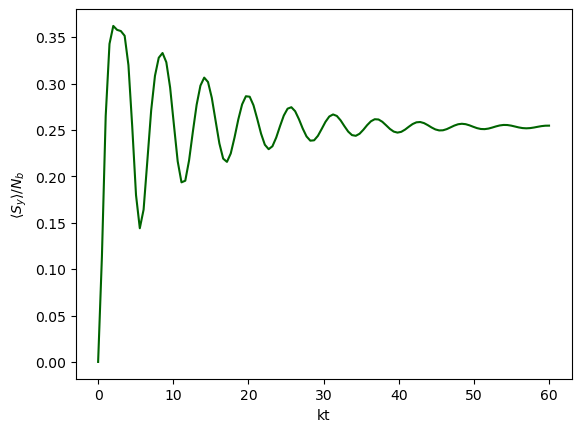

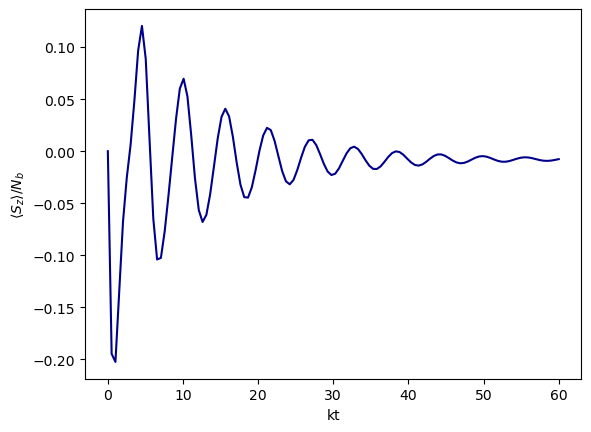

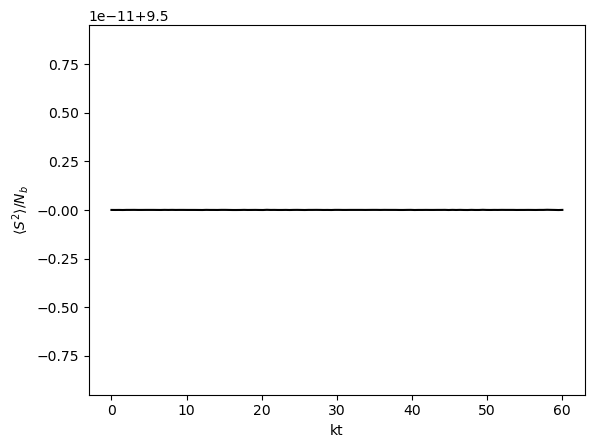

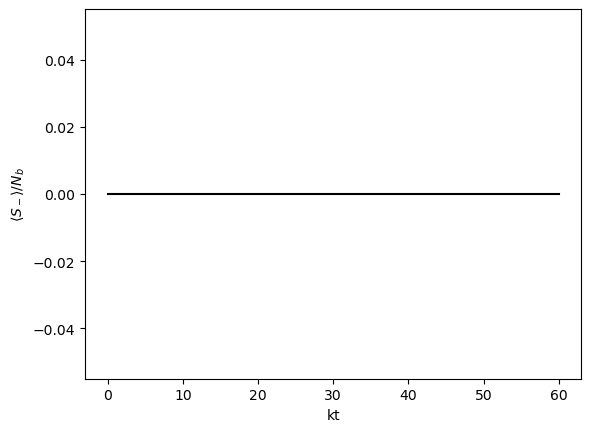

In [4]:
# rho0 = all spin up in z


plt.plot( k*t, evo2.expect[1]/Nb, c='darkred')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_x\rangle / N_b$")
plt.show()

plt.plot( k*t, evo2.expect[2]/Nb, c='darkgreen')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_y\rangle / N_b$")
plt.show()

plt.plot( k*t, evo2.expect[3]/Nb, c='darkblue')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_z\rangle / N_b$")
#plt.savefig("dyn100z.png")
plt.show()


plt.plot( k*t, evo2.expect[0]/Nb, c='black')
plt.xlabel("kt")
plt.ylabel(r"$\langle S^2\rangle / N_b$")
plt.show()

plt.plot( k*t, evo2.expect[4]/Nb, c='black')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_-\rangle / N_b$")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

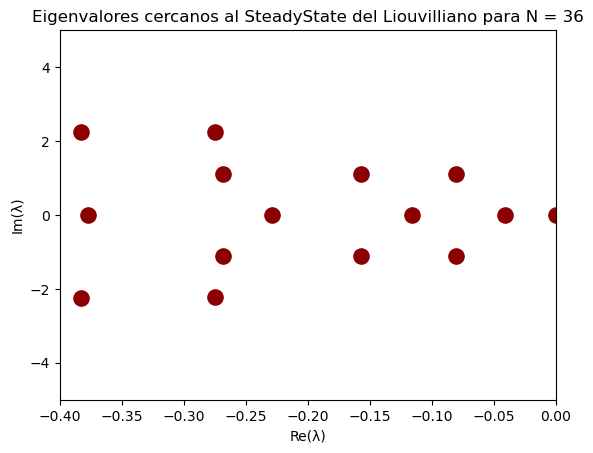

In [5]:
plt.scatter(X,Y, s=120, c='darkred')
plt.title("Eigenvalores cercanos al SteadyState del Liouvilliano para N = 36")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.xlim(-0.4,0)
plt.ylim(-5,5)
plt.show

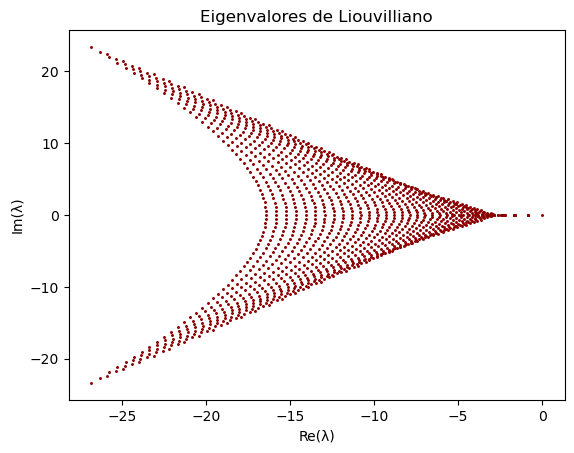

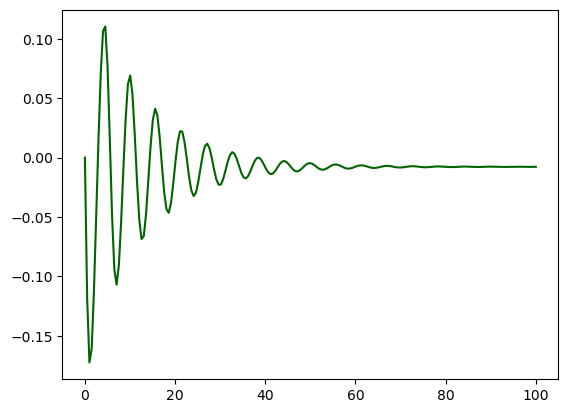

In [38]:
k = 1
w_0 = 0.5*k
# Defining spin operators
Sx = jmat(S, 'x')
Sm = np.sqrt(k/S)*jmat(S, '-')
#Sp = np.sqrt(k/S)*jmat(S, '+')


H = w_0*Sx

jump_ops = [Sm]

L = liouvillian(H, jump_ops)
eigs = L.eigenenergies()

X = np.real(eigs)
Y = np.imag(eigs)

plt.scatter(X,Y, s=1.25, c='darkred')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalores de Liouvilliano")
plt.show()

plt.plot( k*t, evo1.expect[0]/Nb, c='darkgreen')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

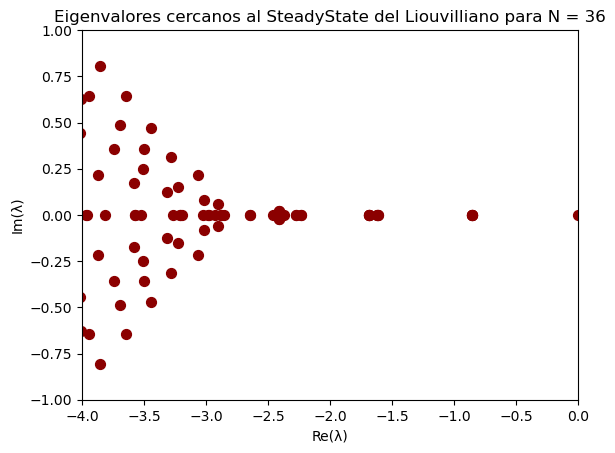

In [23]:
plt.scatter(X,Y, s=50, c='darkred')
plt.title("Eigenvalores cercanos al SteadyState del Liouvilliano para N = 36")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.xlim(-4,0)
plt.ylim(-1,1)
plt.show